## Классификация поворота текста - Ефремова О.


Рассматривается следующая задача: для каждого текстового бокса,
вырезанного из фотографии, требуется оценить вероятность p_180 того,
что данный бокс повёрнут на 180 градусов относительно исходной
ориентации. Используемая метрика качества — Brier score,
то есть среднеквадратичное отклонение предсказанной вероятности от
истинного бинарного значения. Важное следствие выбора этой метрики:
модель штрафуется не только за ошибочный класс, но и за избыточную
уверенность в неверном ответе, поэтому задача калибровки вероятностей
приобретает такое же значение, как и задача классификации как таковой.

## Импорт библиотек и фиксация воспроизводимости


На данном этапе выполняется импорт необходимых библиотек и фиксация
генераторов случайных чисел. Фиксация seed для random, numpy и torch,
а также включение torch.use_deterministic_algorithms, необходимы для
того, чтобы результаты эксперимента можно было воспроизвести повторно
и чтобы различия между запусками объяснялись изменениями в коде, а не
случайностью инициализации.

In [ ]:
import io
import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image, ImageOps, ImageFilter
from scipy.special import expit
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

Device: mps


## Конфигурация путей и гиперпараметров


Здесь задаются пути к данным и основные гиперпараметры.
Размер полосы IMG_H x IMG_W выбран с учётом характерной формы текстовых
боксов (существенно шире, чем выше) и по аналогии с входным разрешением,
традиционно используемым в архитектурах распознавания текстовых строк
(CRNN и подобные).

Отдельно вводится каталог CHECKPOINTS_DIR для сохранения весов обученных
моделей и истории обучения. Флаг FORCE_RETRAIN предусмотрен для случая, 
когда повторное обучение всё же требуется намеренно 
(например, после изменения архитектуры модели или
состава обучающих данных).

In [ ]:
PROJECT_DIR = Path.cwd()
TEST_DIR = PROJECT_DIR / "test"
SAMPLE_SUB_PATH = TEST_DIR / "sample_submission.csv"
IMAGES_DIR = TEST_DIR / "test" / "images"
OUT_PATH = PROJECT_DIR / "submission.csv"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False   # True - игнорировать сохранённые чекпоинты и обучить заново

assert IMAGES_DIR.exists(), f"Не найдена папка с тестовыми картинками: {IMAGES_DIR}"

IMG_H, IMG_W = 32, 160

BATCH_SIZE = 256
EPOCHS = 8
FINETUNE_EPOCHS = 3            # количество эпох дообучения на псевдоразметке
LR_HEAD = 3e-3
LR_FINETUNE = 5e-4             # пониженная скорость обучения на этапе self-training,
                                # поскольку псевдометки заведомо шумнее исходных
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

N_SEEDS = 3                     # число независимых моделей в ансамбле
PSEUDO_N_UNLABELED = 20000       # объём выборки реальных тестовых изображений для self-training
PSEUDO_CONF_THRESH = 0.9         # порог уверенности предсказания
PSEUDO_CONSISTENCY_TOL = 0.1     # допустимое отклонение суммы p(x) + p(rot(x)) от единицы

## Этап предобработки изображений


Основная задача данного этапа — привести изображения произвольного
размера к единому формату без искажения геометрии символов.

In [ ]:
def to_strip(img: Image.Image, target_h: int = IMG_H, target_w: int = IMG_W) -> Image.Image:
    """Приведение изображения к grayscale-полосе фиксированного размера
    с сохранением исходного соотношения сторон."""
    img = img.convert("L")
    w, h = img.size
    new_w = max(1, round(w * target_h / max(h, 1)))
    img = img.resize((new_w, target_h), Image.BILINEAR)

    if new_w >= target_w:
        left = (new_w - target_w) // 2
        img = img.crop((left, 0, left + target_w, target_h))
    else:
        fill = int(np.asarray(img).mean())
        pad_total = target_w - new_w
        pad_l = pad_total // 2
        pad_r = pad_total - pad_l
        img = ImageOps.expand(img, border=(pad_l, 0, pad_r, 0), fill=fill)
    return img

# Проблема: обычные свёрточные слои "не знают", где именно в кадре находится тот или иной признак.
# Они хорошо находят признаки (края, углы, штрихи), но не различают, встретился ли этот признак 
# в верхней части картинки или в нижней — для свёртки это одно и то же, просто сдвинутое на несколько пикселей.
# А в нашей задаче это принципиально: чтобы понять, перевёрнут текст или нет, нужно знать, где именно у букв "верх",
#  а где "низ". Без информации об абсолютном положении пикселя по вертикали свёрточная сеть вынуждена восстанавливать
# её косвенно — через глубину и комбинации признаков, что сложнее и менее надёжно.
# Решение: подмешиваем к изображению второй канал, в котором записана нормированная координата строки. 
# Значения плавно меняются от -1 (верх картинки) до +1 (низ картинки). 
# Теперь у сети есть прямой доступ к "вертикальной позиции" каждого пикселя,
# и задача определения ориентации решается существенно проще.

_ROW_POS = np.linspace(-1.0, 1.0, IMG_H, dtype=np.float32)[:, None]
_ROW_POS_MAP = np.repeat(_ROW_POS, IMG_W, axis=1)  # [H, W]


def strip_to_tensor(strip_img: Image.Image) -> torch.Tensor:
    """Преобразование полосы (PIL, grayscale) в тензор формы [2, H, W]:
    первый канал — нормированная яркость, второй — координата строки."""
    arr = np.asarray(strip_img, dtype=np.float32) / 255.0
    arr = (arr - 0.5) / 0.5
    stacked = np.stack([arr, _ROW_POS_MAP], axis=0)
    return torch.from_numpy(stacked.astype(np.float32))

## Аугментации обучающей выборки


Поскольку используемый далее датасет (TextOCR) содержит преимущественно отдельные слова, вырезанные
в условиях, отличных от условий формирования целевых тестовых боксов,
на данном этапе вносятся искусственные искажения, приближающие
распределение обучающих данных к распределению тестовых. В частности,
реальный бокс, полученный детектором текста, зачастую содержит не одно
слово, а последовательность из нескольких слов, поэтому вводится
конкатенация нескольких примеров в одну строку.

In [ ]:
def concat_words(hf_split, base_idx: int, max_extra: int = 2) -> Image.Image:
    """Конкатенация 1–3 изображений слов в одну горизонтальную строку
    с фиксированным зазором. Моделирует случай, когда текстовый бокс
    содержит несколько слов, а не одно."""
    imgs = [hf_split[base_idx]["image"].convert("L")]
    n_extra = random.choices([0, 1, 2], weights=[0.5, 0.3, 0.2])[0]
    n_extra = min(n_extra, max_extra)
    for _ in range(n_extra):
        j = random.randrange(len(hf_split))
        imgs.append(hf_split[j]["image"].convert("L"))

    if len(imgs) == 1:
        return imgs[0]

    target_h = max(im.size[1] for im in imgs)
    resized = []
    for im in imgs:
        w, h = im.size
        new_w = max(1, round(w * target_h / h))
        resized.append(im.resize((new_w, target_h), Image.BILINEAR))

    gap = 6
    total_w = sum(im.size[0] for im in resized) + gap * (len(resized) - 1)
    fill = int(np.mean([np.asarray(im).mean() for im in resized]))
    canvas = Image.new("L", (total_w, target_h), color=fill)
    x = 0
    for im in resized:
        canvas.paste(im, (x, 0))
        x += im.size[0] + gap
    return canvas


def random_crop_scale(img: Image.Image) -> Image.Image:
    """Случайный кроп с масштабированием и небольшим поворотом (в
    пределах ±6 градусов, что не следует путать с целевым поворотом
    на 180 градусов). Моделирует неидеальность работы детектора боксов."""
    w, h = img.size
    scale = random.uniform(0.85, 1.0)
    cw, ch = max(int(w * scale), 4), max(int(h * scale), 4)
    x0 = random.randint(0, max(w - cw, 0))
    y0 = random.randint(0, max(h - ch, 0))
    img = img.crop((x0, y0, x0 + cw, y0 + ch))
    if random.random() < 0.5:
        fill = int(np.asarray(img.convert("L")).mean())
        img = img.rotate(random.uniform(-6, 6), fillcolor=fill)
    return img


def photo_artifacts(img: Image.Image) -> Image.Image:
    """Внесение лёгкого размытия и артефактов JPEG-компрессии. Исходные
    кропы TextOCR визуально более чисты, чем типичная фотография с
    мобильного устройства, поэтому соответствующий шум добавляется
    отдельно на этапе аугментации."""
    if random.random() < 0.25:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.0)))
    if random.random() < 0.3:
        buf = io.BytesIO()
        img.convert("RGB").save(buf, format="JPEG", quality=random.randint(35, 75))
        buf.seek(0)
        img = Image.open(buf).convert("L")
    return img


def augment_pixels(arr: np.ndarray) -> np.ndarray:
    """Пиксельные аугментации: аддитивный шум, изменение яркости и
    контраста, а также инверсия полярности (тёмный текст на светлом фоне
    и наоборот), поскольку оба варианта равновероятно встречаются в
    реальных данных."""
    if random.random() < 0.3:
        arr = arr + np.random.normal(0, 0.03, arr.shape).astype(np.float32)
    if random.random() < 0.3:
        b, c = random.uniform(-0.15, 0.15), random.uniform(0.85, 1.15)
        arr = arr * c + b
    if random.random() < 0.15:
        arr = 1.0 - arr
    return np.clip(arr, 0.0, 1.0).astype(np.float32)

## Классы датасетов


RotationDataset реализует описанный ранее принцип автоматической
разметки: чётные индексы соответствуют исходному изображению (класс 0),
нечётные — тому же изображению, повёрнутому на 180 градусов (класс 1).
Аугментации применяются только к обучающей части выборки; валидационная
выборка остаётся неизменной, поскольку используется для объективной
оценки качества модели.

In [ ]:
class RotationDataset(Dataset):
    def __init__(self, hf_split, train: bool):
        self.hf = hf_split
        self.train = train

    def __len__(self):
        return 2 * len(self.hf)

    def __getitem__(self, idx):
        base_idx = idx // 2
        flip = idx % 2

        if self.train:
            img = concat_words(self.hf, base_idx)
            img = random_crop_scale(img)
        else:
            img = self.hf[base_idx]["image"]

        if flip:
            img = img.rotate(180)

        strip = to_strip(img)
        if self.train:
            strip = photo_artifacts(strip)
            arr = np.asarray(strip, dtype=np.float32) / 255.0
            arr = augment_pixels(arr)
            arr = (arr - 0.5) / 0.5
            stacked = np.stack([arr, _ROW_POS_MAP], axis=0)
            tensor = torch.from_numpy(stacked.astype(np.float32))
        else:
            tensor = strip_to_tensor(strip)
        return tensor, float(flip)


class TestDataset(Dataset):
    """Датасет тестовых изображений без разметки. Параметр rotate180
    используется для реализации аугментации: каждое изображение
    обрабатывается как в исходном виде, так и в повёрнутом, после чего
    предсказания усредняются."""

    def __init__(self, image_paths, rotate180: bool = False):
        self.image_paths = image_paths
        self.rotate180 = rotate180

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path)
        if self.rotate180:
            img = img.rotate(180)
        strip = to_strip(img)
        tensor = strip_to_tensor(strip)
        return tensor, path.stem


class PseudoLabelDataset(Dataset):
    """Датасет тестовых изображений с псевдометками, полученными на
    этапе self-training. В отличие от RotationDataset, метка здесь не
    является гарантированно верной, поэтому в псевдоразметку попадают
    только те примеры, которые прошли фильтрацию по уверенности и
    согласованности предсказаний (см. соответствующий раздел ниже)."""

    def __init__(self, image_paths, pseudo_labels):
        self.image_paths = image_paths
        self.pseudo_labels = pseudo_labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx])
        label = self.pseudo_labels[idx]
        if random.random() < 0.5:
            img = img.rotate(180)
            label = 1.0 - label
        strip = to_strip(img)
        arr = np.asarray(strip, dtype=np.float32) / 255.0
        arr = augment_pixels(arr)
        arr = (arr - 0.5) / 0.5
        stacked = np.stack([arr, _ROW_POS_MAP], axis=0)
        return torch.from_numpy(stacked.astype(np.float32)), float(label)

## Архитектура модели


Используется компактная свёрточная сеть с двумя входными каналами
(яркость и координата строки). Выбор в пользу
лёгкой архитектуры обусловлен характером задачи: бинарная классификация
ориентации текста существенно проще по сложности, чем классификация,
для которой такие архитектуры изначально разрабатывались.
Кроме того, с учётом объёма данных, подлежащих обработке в промышленной
эксплуатации (миллионы изображений в сутки), компактность модели
напрямую определяет практическую применимость решения.

In [ ]:
class TinyOrientationNet(nn.Module):
    def __init__(self, in_channels: int = 2):
        super().__init__()

        def block(cin, cout, stride=2):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
            )

        self.features = nn.Sequential(
            block(in_channels, 24),  # 32x160 -> 16x80
            block(24, 48),           # -> 8x40
            block(48, 96),           # -> 4x20
            block(96, 128),          # -> 2x10
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


def build_model() -> nn.Module:
    return TinyOrientationNet()

## Вспомогательные функции: обучение, оценка, калибровка


Ниже приведены стандартные для задачи бинарной классификации функции
обучения одной эпохи и оценки на валидационной выборке. Отдельного
рассмотрения заслуживает функция fit_temperature, реализующая метод
"temperature scaling". Существенно, что подбор температуры выполняется
исключительно по критерию минимизации Brier score на отложенной выборке
и не опирается на какие-либо предположения о распределении классов
в тестовой выборке.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running = 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device).unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running += loss.item() * images.size(0)
    return running / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    probs_all, targets_all = [], []
    for images, labels in loader:
        images = images.to(device)
        probs = torch.sigmoid(model(images)).squeeze(1).cpu().numpy()
        probs_all.append(probs)
        targets_all.append(labels.numpy())
    probs = np.concatenate(probs_all)
    targets = np.concatenate(targets_all)
    return float(np.mean((probs - targets) ** 2)), probs, targets


@torch.no_grad()
def get_logits(model, loader, device):
    model.eval()
    logits_all, extra_all = [], []
    for images, extra in loader:
        images = images.to(device)
        logits_all.append(model(images).squeeze(1).cpu().numpy())
        extra_all.append(extra)
    logits = np.concatenate(logits_all)
    if isinstance(extra_all[0], torch.Tensor):
        extra = np.concatenate([e.numpy() for e in extra_all])
    else:
        extra = [x for batch in extra_all for x in batch]
    return logits, extra


def fit_temperature(logits: np.ndarray, targets: np.ndarray):
    """Поиск температуры T, минимизирующей Brier score на валидационной
    выборке, методом полного перебора по сетке значений. Наряду с
    оптимальным значением возвращается вся кривая зависимости метрики от
    температуры, что позволяет впоследствии визуально удостовериться в
    наличии выраженного минимума внутри рассматриваемого диапазона."""
    T_grid = np.linspace(0.3, 3.0, 300)
    briers = np.array([np.mean((expit(logits / T) - targets) ** 2) for T in T_grid])
    best_T = float(T_grid[int(np.argmin(briers))])
    return best_T, T_grid, briers


def train_model(seed: int, train_dataset, val_loader):
    """Обучение одной модели ансамбля при фиксированном значении seed.
    Возвращает обученную модель, наилучшее достигнутое значение Brier
    score на валидации и историю метрик по эпохам"""
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
    )
    model = build_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_brier": []}
    best_brier, best_state = float("inf"), None

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, loader, criterion, optimizer, DEVICE)
        val_brier, _, _ = evaluate(model, val_loader, DEVICE)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_brier"].append(val_brier)

        marker = ""
        if val_brier < best_brier:
            best_brier = val_brier
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            marker = "  <- best"
        print(f"  [seed {seed}] epoch {epoch:>2} | loss {train_loss:.4f} | "
              f"val_brier {val_brier:.4f} | {time.time() - t0:.1f}s{marker}")

    model.load_state_dict(best_state)
    return model.to(DEVICE), best_brier, history


def checkpoint_paths(seed: int, tag: str):
    """Формирует пути к файлу весов и файлу истории обучения для заданных
    seed и метки этапа. Метка используется для различения весов до
    и после этапа self-training (например, "base" и "finetuned"), поскольку
    это фактически разные состояния одной и той же модели."""
    ckpt_path = CHECKPOINTS_DIR / f"orientation_net_seed{seed}_{tag}.pt"
    history_path = CHECKPOINTS_DIR / f"orientation_net_seed{seed}_{tag}_history.json"
    return ckpt_path, history_path


def save_checkpoint(model: nn.Module, history: dict, seed: int, tag: str) -> None:
    """Сохраняет веса модели и историю обучения на диск."""
    ckpt_path, history_path = checkpoint_paths(seed, tag)
    torch.save(model.state_dict(), ckpt_path)
    with open(history_path, "w", encoding="utf-8") as f:
        json.dump(history, f)
    print(f"  Чекпоинт сохранён: {ckpt_path.name}")


def load_checkpoint_if_exists(seed: int, tag: str):
    """Проверяет наличие сохранённого чекпоинта для заданных seed и tag.
    При наличии файла (и при FORCE_RETRAIN=False) возвращает восстановленную
    модель и историю обучения; в противном случае возвращает None, что
    служит сигналом для последующего запуска обучения с нуля."""
    ckpt_path, history_path = checkpoint_paths(seed, tag)
    if FORCE_RETRAIN or not ckpt_path.exists():
        return None

    model = build_model().to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    history = {"train_loss": [], "val_brier": []}
    if history_path.exists():
        with open(history_path, encoding="utf-8") as f:
            history = json.load(f)

    print(f"  Найден чекпоинт {ckpt_path.name} — модель загружена без переобучения")
    return model, history

## Графики обучения


В данном разделе определены функции построения графиков, используемые
на последующих этапах для визуализации обучения: итоговое
значение Brier score само по себе не позволяет отличить хорошо
откалиброванную модель от модели, качество которой является следствием
компенсации ошибок разного знака.

In [ ]:
def plot_training_curves(histories: dict):
    """Построение кривых обучения (train loss и val Brier по эпохам)
    для каждой модели ансамбля. Существенное расхождение кривых между
    моделями может указывать на неустойчивость обучения при данном
    наборе гиперпараметров."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for seed, hist in histories.items():
        epochs = range(1, len(hist["train_loss"]) + 1)
        axes[0].plot(epochs, hist["train_loss"], marker="o", label=f"seed {seed}")
        axes[1].plot(epochs, hist["val_brier"], marker="o", label=f"seed {seed}")

    axes[0].set_title("Train loss по эпохам")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("BCE loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title("Val Brier по эпохам")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("Brier score (меньше — лучше)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_temperature_search(T_grid, briers, best_T, title=""):
    """Визуализация зависимости Brier score от температуры калибровки.
    Наличие выраженного минимума внутри диапазона сетки подтверждает
    корректность процедуры подбора; расположение минимума на границе
    диапазона указывает на необходимость расширения сетки поиска."""
    plt.figure(figsize=(6, 4))
    plt.plot(T_grid, briers)
    plt.axvline(best_T, color="red", linestyle="--", label=f"оптимальная T = {best_T:.3f}")
    plt.xlabel("Температура T")
    plt.ylabel("Val Brier")
    plt.title(f"Подбор температуры калибровки {title}".strip())
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_reliability_diagram(probs, targets, n_bins: int = 10, title=""):
    """Диаграмма надёжности: предсказанные
    вероятности группируются в бины, для каждого из которых сопоставляется
    средняя предсказанная вероятность и эмпирическая доля положительного
    класса. Совпадение точек с диагональю свидетельствует о корректной
    калибровке; систематическое отклонение вверх или вниз от диагонали —
    о недостаточной либо избыточной уверенности модели соответственно."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(probs, bins) - 1, 0, n_bins - 1)

    bin_conf = np.full(n_bins, np.nan)
    bin_acc = np.full(n_bins, np.nan)
    bin_counts = np.zeros(n_bins)
    for b in range(n_bins):
        mask = bin_ids == b
        bin_counts[b] = mask.sum()
        if mask.sum() > 0:
            bin_conf[b] = probs[mask].mean()
            bin_acc[b] = targets[mask].mean()

    valid = ~np.isnan(bin_conf)
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], "k--", label="идеальная калибровка")
    plt.plot(bin_conf[valid], bin_acc[valid], marker="o", label="модель")
    plt.xlabel("Предсказанная вероятность (среднее по бину)")
    plt.ylabel("Эмпирическая доля класса 1 в бине")
    plt.title(f"Reliability diagram {title}".strip())
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_confidence_hist(probs, title=""):
    """Гистограмма распределения предсказанных вероятностей. Сопоставление
    данной гистограммы для валидационной и тестовой выборок позволяет
    выявить расхождение доменов: резкое изменение формы
    распределения на тестовых данных при отсутствии такового на валидации
    свидетельствует о том, что модель ведёт себя на реальных данных иначе,
    чем можно было бы заключить по метрике на валидационной выборке."""
    plt.figure(figsize=(6, 4))
    plt.hist(probs, bins=40, range=(0, 1))
    plt.xlabel("p_180")
    plt.ylabel("Количество примеров")
    plt.title(f"Распределение предсказанных вероятностей {title}".strip())
    plt.grid(alpha=0.3)
    plt.show()


def plot_tta_consistency(probs_orig, probs_rot, title=""):
    """Гистограмма суммы p(x) + p(rot180(x)). По построению данная сумма
    должна быть близка к единице: предсказание для изображения и
    предсказание для его поворота на 180 градусов являются, по сути,
    оценками одной и той же величины с противоположным знаком. Существенное
    отклонение распределения от единицы указывает на внутреннюю
    противоречивость предсказаний модели на рассматриваемой выборке."""
    total = np.asarray(probs_orig) + np.asarray(probs_rot)
    plt.figure(figsize=(6, 4))
    plt.hist(total, bins=40)
    plt.axvline(1.0, color="red", linestyle="--", label="ожидаемое значение: p(x) + p(rot(x)) = 1")
    plt.xlabel("p(x) + p(rot180(x))")
    plt.ylabel("Количество примеров")
    plt.title(f"Согласованность TTA {title}".strip())
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## Загрузка обучающих данных


В качестве единственного источника обучающих данных используется датасет
TextOCR (MiXaiLL76/TextOCR_OCR) — набор вырезанных слов из реальных
фотографий. Разбиение train/test в исходном датасете сформировано из
непересекающихся исходных изображений, что исключает утечку данных между
обучающей и валидационной выборками.

In [ ]:
from datasets import load_dataset

print("Загружаю MiXaiLL76/TextOCR_OCR...")
textocr = load_dataset("MiXaiLL76/TextOCR_OCR")
textocr = {"train": textocr["train"], "validation": textocr["test"]}
print({k: len(v) for k, v in textocr.items()})

train_dataset = RotationDataset(textocr["train"], train=True)
val_dataset = RotationDataset(textocr["validation"], train=False)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
)
print(f"Train примеров: {len(train_dataset)} | Val примеров: {len(val_dataset)}")

Загружаю MiXaiLL76/TextOCR_OCR (реальные фотографии, английский язык)...
{'train': 91373, 'validation': 14669}
Train примеров: 182746 | Val примеров: 29338


## Обучение ансамбля моделей


На данном этапе обучается N_SEEDS независимых моделей одной архитектуры,
различающихся исключительно значением seed. Предсказания ансамбля усредняются на этапе
предсказания, что представляет собой стандартный приём снижения дисперсии
оценки: случайные ошибки отдельных моделей, обусловленные конкретной
инициализацией, частично компенсируют друг друга при усреднении.

Перед обучением каждой модели выполняется проверка наличия сохранённого
чекпоинта (см. функцию load_checkpoint_if_exists выше). При повторном
запуске ноутбука это позволяет не повторять затратную по времени
процедуру обучения, а восстановить ранее полученные веса с диска.


=== Модель 1/3 (seed=42) ===
  [seed 42] epoch  1 | loss 0.6115 | val_brier 0.2037 | 273.0s  <- best
  [seed 42] epoch  2 | loss 0.5297 | val_brier 0.2129 | 272.3s
  [seed 42] epoch  3 | loss 0.4615 | val_brier 0.1587 | 278.3s  <- best
  [seed 42] epoch  4 | loss 0.4185 | val_brier 0.1598 | 273.1s
  [seed 42] epoch  5 | loss 0.3916 | val_brier 0.1453 | 268.3s  <- best
  [seed 42] epoch  6 | loss 0.3717 | val_brier 0.1394 | 268.3s  <- best
  [seed 42] epoch  7 | loss 0.3600 | val_brier 0.1360 | 264.3s  <- best
  [seed 42] epoch  8 | loss 0.3555 | val_brier 0.1349 | 262.8s  <- best
  Чекпоинт сохранён: orientation_net_seed42_base.pt

=== Модель 2/3 (seed=43) ===
  [seed 43] epoch  1 | loss 0.6277 | val_brier 0.2393 | 266.0s  <- best
  [seed 43] epoch  2 | loss 0.5497 | val_brier 0.1957 | 277.0s  <- best
  [seed 43] epoch  3 | loss 0.4716 | val_brier 0.2051 | 279.5s
  [seed 43] epoch  4 | loss 0.4272 | val_brier 0.1531 | 268.4s  <- best
  [seed 43] epoch  5 | loss 0.3985 | val_brier 0.14

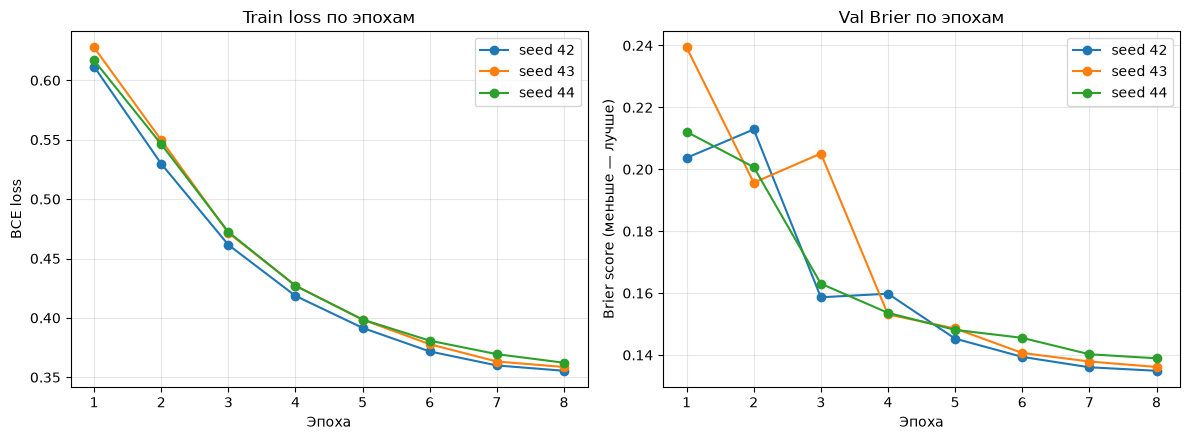

In [ ]:
SEEDS = [SEED, SEED + 1, SEED + 2][:N_SEEDS]

models = []
histories = {}
for i, seed in enumerate(SEEDS):
    print(f"\n=== Модель {i + 1}/{N_SEEDS} (seed={seed}) ===")
    cached = load_checkpoint_if_exists(seed, tag="base")
    if cached is not None:
        m, hist = cached
        brier, _, _ = evaluate(m, val_loader, DEVICE)
    else:
        m, brier, hist = train_model(seed, train_dataset, val_loader)
        save_checkpoint(m, hist, seed, tag="base")
    models.append(m)
    histories[seed] = hist

n_params = sum(p.numel() for p in models[0].parameters())
print(f"\nПараметров в одной модели: {n_params:,} | Моделей в ансамбле: {len(models)}")

# Визуальный контроль устойчивости обучения: кривые всех моделей ансамбля
# должны демонстрировать сходное поведение без резких выбросов метрики.
plot_training_curves(histories)


def ensemble_logits(models, loader, device):
    """Усреднение предсказаний ансамбля производится в пространстве
    вероятностей (после применения сигмоиды), а не в пространстве
    логитов, поскольку отдельные модели не приведены к единой температурной
    шкале и усреднение их логитов было бы методологически некорректным."""
    all_probs = []
    for m in models:
        logits, extra = get_logits(m, loader, device)
        all_probs.append(expit(logits))
    return np.mean(all_probs, axis=0), extra

## Калибровка ансамбля методом температурного шкалирования


На данном этапе выполняется калибровка усреднённых предсказаний ансамбля
на валидационной выборке. Как отмечено выше, подбор температуры
не опирается на предположения о балансе классов в тестовой выборке.
Построение кривой подбора температуры и диаграмм надёжности до и после
калибровки позволяет понять, что процедура калибровки
выполнена корректно.


Ансамбль на val: Brier без калибровки=0.1321 -> с калибровкой=0.1308 (T=0.770)


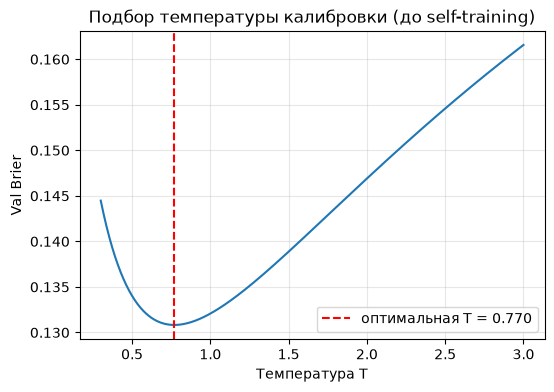

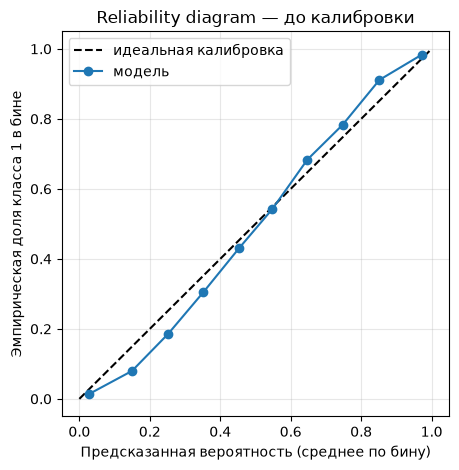

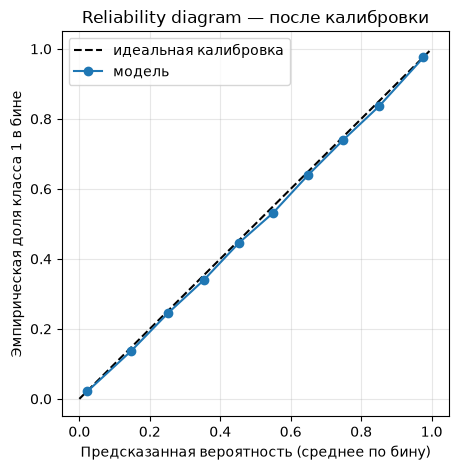

In [ ]:
val_probs_ens, val_targets = ensemble_logits(models, val_loader, DEVICE)
val_logits_ens = np.log(np.clip(val_probs_ens, 1e-6, 1 - 1e-6) / np.clip(1 - val_probs_ens, 1e-6, 1 - 1e-6))

best_T, T_grid, briers_curve = fit_temperature(val_logits_ens, val_targets)
brier_raw = float(np.mean((val_probs_ens - val_targets) ** 2))
brier_cal = float(np.mean((expit(val_logits_ens / best_T) - val_targets) ** 2))
print(f"\nАнсамбль на val: Brier без калибровки={brier_raw:.4f} -> "
      f"с калибровкой={brier_cal:.4f} (T={best_T:.3f})")

plot_temperature_search(T_grid, briers_curve, best_T, title="(до self-training)")
plot_reliability_diagram(val_probs_ens, val_targets, title="— до калибровки")
plot_reliability_diagram(expit(val_logits_ens / best_T), val_targets, title="— после калибровки")

## Самообучение (self-training) на неразмеченных тестовых данных


Все предшествующие этапы направлены на оптимизацию метрики внутри
домена обучающих данных (TextOCR), тогда как целевые тестовые данные
представляют собой отдельный домен. Для частичной компенсации расхождения 
между ними применяется метод самообучения: используется свойство согласованности
тест-тайм аугментации (p(x) + p(rot(x)) ≈ 1) в качестве критерия отбора
надёжных псевдометок среди неразмеченных тестовых примеров, на которых
производится последующее дообучение модели.


Всего тестовых изображений: 20000


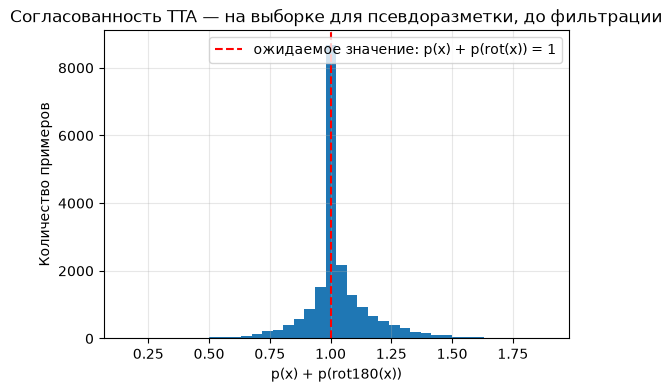

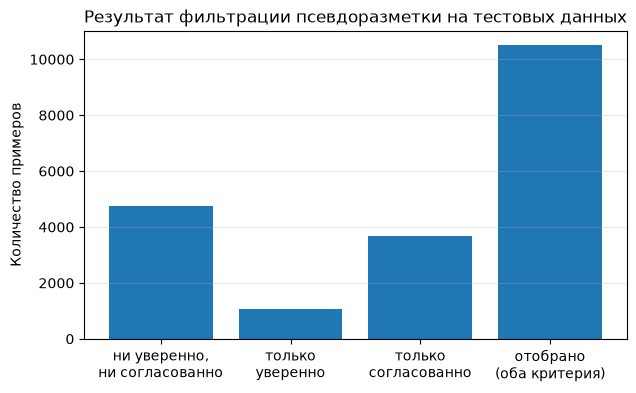

Псевдоразметка: отобрано 10494/20000 (52.5%) примеров, удовлетворяющих критериям уверенности и согласованности

Дообучение в течение 3 эпох на объединении train и 10494 псевдоразмеченных примеров (LR=0.0005, значение понижено с целью ограничить влияние шума в псевдометках)
  [модель 1] finetune epoch 1 | loss 0.3356 | val_brier 0.1364
  [модель 1] finetune epoch 2 | loss 0.3333 | val_brier 0.1350
  [модель 1] finetune epoch 3 | loss 0.3283 | val_brier 0.1353
  Чекпоинт сохранён: orientation_net_seed42_finetuned.pt
  [модель 2] finetune epoch 1 | loss 0.3396 | val_brier 0.1355
  [модель 2] finetune epoch 2 | loss 0.3347 | val_brier 0.1356
  [модель 2] finetune epoch 3 | loss 0.3309 | val_brier 0.1348
  Чекпоинт сохранён: orientation_net_seed43_finetuned.pt
  [модель 3] finetune epoch 1 | loss 0.3447 | val_brier 0.1401
  [модель 3] finetune epoch 2 | loss 0.3420 | val_brier 0.1393
  [модель 3] finetune epoch 3 | loss 0.3378 | val_brier 0.1361
  Чекпоинт сохранён: orientation_net_seed44_f

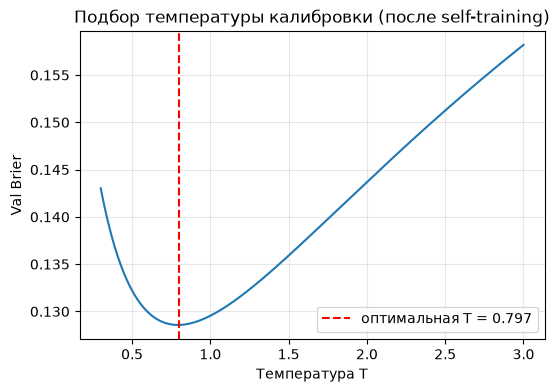

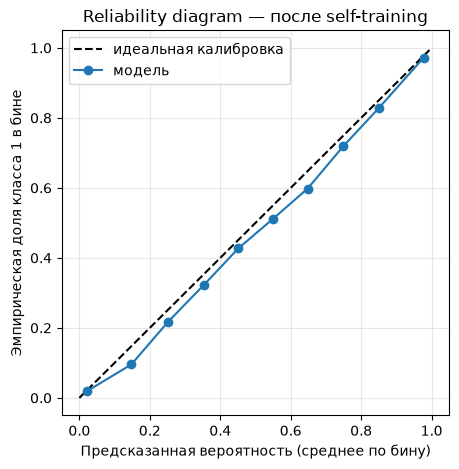

In [ ]:
all_test_paths = sorted(
    p for p in IMAGES_DIR.iterdir() if p.is_file() and not p.name.startswith(".")
)
print(f"\nВсего тестовых изображений: {len(all_test_paths)}")

rng = random.Random(SEED)
pseudo_pool = rng.sample(all_test_paths, min(PSEUDO_N_UNLABELED, len(all_test_paths)))

pseudo_loader_orig = DataLoader(
    TestDataset(pseudo_pool, rotate180=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
)
pseudo_loader_rot = DataLoader(
    TestDataset(pseudo_pool, rotate180=True),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
)

probs_orig_raw, ids_orig = ensemble_logits(models, pseudo_loader_orig, DEVICE)
probs_rot_raw, ids_rot = ensemble_logits(models, pseudo_loader_rot, DEVICE)
assert ids_orig == ids_rot, "Порядок id разошёлся между orig и rot loader'ами"

# Оценка согласованности TTA до применения фильтрации: существенное
# отклонение распределения от единицы указывало бы на пониженную
# надёжность self-training на данном источнике тестовых данных.
plot_tta_consistency(probs_orig_raw, probs_rot_raw, title="— на выборке для псевдоразметки, до фильтрации")

confident = np.abs(probs_orig_raw - 0.5) > (PSEUDO_CONF_THRESH - 0.5)
consistent = np.abs((probs_orig_raw + probs_rot_raw) - 1.0) < PSEUDO_CONSISTENCY_TOL
keep_mask = confident & consistent

neither = (~confident & ~consistent).sum()
only_confident = (confident & ~consistent).sum()
only_consistent = (~confident & consistent).sum()
kept_count = keep_mask.sum()

plt.figure(figsize=(7, 4))
plt.bar(
    ["ни уверенно,\nни согласованно", "только\nуверенно", "только\nсогласованно", "отобрано\n(оба критерия)"],
    [neither, only_confident, only_consistent, kept_count],
)
plt.ylabel("Количество примеров")
plt.title("Результат фильтрации псевдоразметки на тестовых данных")
plt.grid(alpha=0.3, axis="y")
plt.show()

kept_paths = [p for p, keep in zip(pseudo_pool, keep_mask) if keep]
kept_labels = [1.0 if p >= 0.5 else 0.0 for p, keep in zip(probs_orig_raw, keep_mask) if keep]
print(f"Псевдоразметка: отобрано {len(kept_paths)}/{len(pseudo_pool)} "
      f"({100 * len(kept_paths) / len(pseudo_pool):.1f}%) примеров, "
      f"удовлетворяющих критериям уверенности и согласованности")

if len(kept_paths) > 200:
    # Аналогично базовому обучению, перед запуском дообучения проверяется
    # наличие уже сохранённых чекпоинтов с меткой "finetuned".
    finetuned_cached = [load_checkpoint_if_exists(seed, tag="finetuned") for seed in SEEDS]

    if all(c is not None for c in finetuned_cached):
        print("Найдены чекпоинты дообученных моделей — этап self-training пропускается, "
              "веса восстановлены с диска.")
        models = [cached[0] for cached in finetuned_cached]
    else:
        pseudo_dataset = PseudoLabelDataset(kept_paths, kept_labels)
        finetune_dataset = ConcatDataset([train_dataset, pseudo_dataset])
        finetune_loader = DataLoader(
            finetune_dataset, batch_size=BATCH_SIZE, shuffle=True,
            num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
        )
        print(f"\nДообучение в течение {FINETUNE_EPOCHS} эпох на объединении train "
              f"и {len(kept_paths)} псевдоразмеченных примеров "
              f"(LR={LR_FINETUNE}, значение понижено с целью ограничить влияние шума в псевдометках)")

        for i, (m, seed) in enumerate(zip(models, SEEDS)):
            optimizer = torch.optim.AdamW(m.parameters(), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY)
            finetune_history = {"train_loss": [], "val_brier": []}
            for epoch in range(1, FINETUNE_EPOCHS + 1):
                loss = train_one_epoch(m, finetune_loader, nn.BCEWithLogitsLoss(), optimizer, DEVICE)
                val_brier, _, _ = evaluate(m, val_loader, DEVICE)
                finetune_history["train_loss"].append(loss)
                finetune_history["val_brier"].append(val_brier)
                print(f"  [модель {i + 1}] finetune epoch {epoch} | loss {loss:.4f} | val_brier {val_brier:.4f}")
            save_checkpoint(m, finetune_history, seed, tag="finetuned")

    val_probs_ens, val_targets = ensemble_logits(models, val_loader, DEVICE)
    val_logits_ens = np.log(np.clip(val_probs_ens, 1e-6, 1 - 1e-6) / np.clip(1 - val_probs_ens, 1e-6, 1 - 1e-6))
    best_T, T_grid, briers_curve = fit_temperature(val_logits_ens, val_targets)
    brier_after = float(np.mean((expit(val_logits_ens / best_T) - val_targets) ** 2))
    print(f"После self-training: val Brier с калибровкой = {brier_after:.4f} "
          f"(до self-training: {brier_cal:.4f})")

    plot_temperature_search(T_grid, briers_curve, best_T, title="(после self-training)")
    plot_reliability_diagram(expit(val_logits_ens / best_T), val_targets, title="— после self-training")
else:
    print("Количество отобранных примеров недостаточно для проведения self-training; "
          "данный этап пропускается во избежание дообучения на статистически "
          "незначимой выборке.")

## Итоговый предсказания на тестовой выборке


На завершающем этапе ансамбль применяется ко всей тестовой выборке
дважды — к исходным изображениям и к их поворотам на 180 градусов, —
после чего вычисляется усреднённая по правилу TTA вероятность.
Дополнительно фиксируется время инференса, что имеет непосредственное
отношение к практической применимости решения при обработке больших
объёмов данных.

test: 100%|██████████| 79/79 [00:19<00:00,  4.03it/s]



Инференс 20000 изображений ансамблем из 3 моделей: 56.8s (~2.842 мс/изображение на mps)


test (rot180): 100%|██████████| 79/79 [00:19<00:00,  4.14it/s]


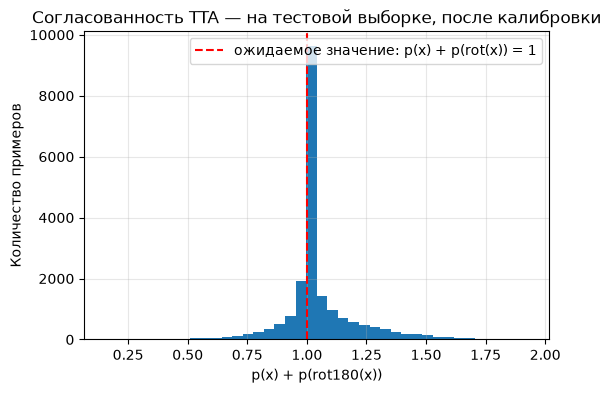

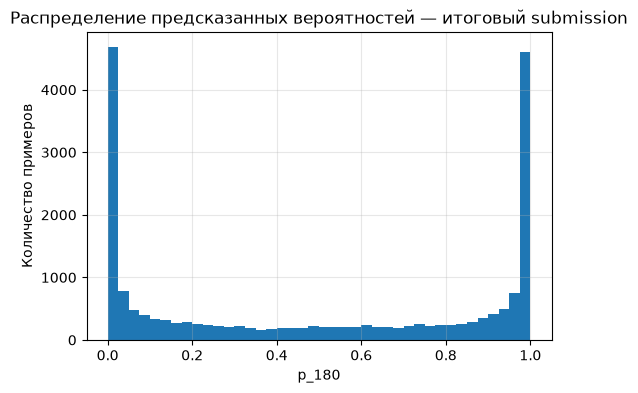

In [ ]:
test_loader_orig = DataLoader(
    TestDataset(all_test_paths, rotate180=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
)
test_loader_rot = DataLoader(
    TestDataset(all_test_paths, rotate180=True),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
)

t0 = time.time()
probs_orig, ids_orig = ensemble_logits(models, tqdm(test_loader_orig, desc="test"), DEVICE)
infer_time = time.time() - t0
print(f"\nИнференс {len(all_test_paths)} изображений ансамблем из {len(models)} моделей: "
      f"{infer_time:.1f}s (~{1000 * infer_time / len(all_test_paths):.3f} мс/изображение на {DEVICE})")

probs_rot, ids_rot = ensemble_logits(models, tqdm(test_loader_rot, desc="test (rot180)"), DEVICE)
assert ids_orig == ids_rot, "Порядок id разошёлся между orig и rot loader'ами"

logits_orig = np.log(np.clip(probs_orig, 1e-6, 1 - 1e-6) / np.clip(1 - probs_orig, 1e-6, 1 - 1e-6))
logits_rot = np.log(np.clip(probs_rot, 1e-6, 1 - 1e-6) / np.clip(1 - probs_rot, 1e-6, 1 - 1e-6))
probs_orig_cal = expit(logits_orig / best_T)
probs_rot_cal = expit(logits_rot / best_T)

probs_tta = (probs_orig_cal + (1.0 - probs_rot_cal)) / 2.0

# Итоговый визуальный контроль: согласованность TTA и общее распределение
# вероятностей на реальных тестовых данных. Существенное расхождение с
# аналогичными характеристиками на валидационной выборке служило бы
# основанием для дополнительного анализа остаточного domain shift.
plot_tta_consistency(probs_orig_cal, probs_rot_cal, title="— на тестовой выборке, после калибровки")
plot_confidence_hist(probs_tta, title="— итоговый submission")

## Формирование итогового файла submission.csv


Заключительный этап — формирование файла результатов в формате,
соответствующем sample_submission.csv, с явной проверкой согласованности
столбцов, порядка строк и допустимости диапазона значений посредством
конструкции assert. Такая проверка целесообразна методологически: она
исключает ситуацию, при которой формально корректно рассчитанные
вероятности оказываются сохранены в файл в неверном формате.

In [ ]:
submission = pd.DataFrame({"image_id": ids_orig, "p_180": probs_tta})

if SAMPLE_SUB_PATH.exists():
    sample = pd.read_csv(SAMPLE_SUB_PATH)
    assert list(submission.columns) == list(sample.columns), "Колонки не совпадают с sample_submission.csv"
    submission = submission.set_index("image_id").loc[sample["image_id"]].reset_index()
    assert len(submission) == len(sample), "Число строк не совпадает с sample_submission.csv"

assert submission["p_180"].between(0, 1).all(), "p_180 вне диапазона [0, 1]"
assert not submission["p_180"].isna().any(), "Есть NaN в p_180"

submission.to_csv(OUT_PATH, index=False)
print(f"\n ГОТОВО: {OUT_PATH} сохранён | строк: {len(submission)} | "
      f"mean(p_180)={submission['p_180'].mean():.3f}")


 ГОТОВО: /Users/oleffr/Desktop/Документы/Резюме/2026/Авито буткэмп/тестовое/project/submission.csv сохранён | строк: 20000 | mean(p_180)=0.497
